In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
import os, sys
import src
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/pytorch_lightning/utilities/seed.py:48: LightningDeprecationWarning: `pytorch_lightning.utilities.seed.seed_everything` has been deprecated in v1.8.0 and will be removed in v2.0.0. Please use `lightning_fabric.utilities.seed.seed_everything` instead.
  rank_zero_deprecation(
Global seed set to 0


In [5]:
from src import PATH
from src import _configure
from src import _diffplot as dfp

/home/wergillius/Project/diffuse_differentiate/script/path_n_util.py
/home/wergillius/Project/diffuse_differentiate/machine_config.json


# load sampling config

In [91]:
meanroot_ad = sc.read_h5ad("/home/wergillius/Project/diffuse_differentiate/data/Perturb_sci/d_preprocessed_Apr11.h5ad")

In [11]:
relative_path = "configs/Perturb-kinetics/PathSampler/a3r10.yaml"
path_delta_x = dfp.sample_Delta_X(yaml_path = relative_path,
                sampling_repeat = 1
                    )
np.save("path_a3r10_deltaX.npy", path_delta_x)

Sample data using dataset class Path_Diffuse
preparing dataloaders ...
loading adata ...
Sampling ...


100%|██████████| 279/279 [03:36<00:00,  1.29it/s]


computing velocity graph (using 30/40 cores)


  0%|          | 0/89273 [00:00<?, ?cells/s]

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/pytorch_lightning/utilities/seed.py:48: LightningDeprecationWarning: `pytorch_lightning.utilities.seed.seed_everything` has been deprecated in v1.8.0 and will be removed in v2.0.0. Please use `lightning_fabric.utilities.seed.seed_everything` instead.
  rank_zero_deprecation(
Global seed set to 0
/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/pytorch_lightning/utilities/seed.py:48: LightningDeprecationWarning: `pytorch_lightning.utilities.seed.seed_everything` has been deprecated in v1.8.0 and will be removed in v2.0.0. Please use `lightning_fabric.utilities.seed.seed_everything` instead.
  rank_zero_deprecation(
Global seed set to 0
/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/pytorch_lightning/utilities/seed.py:48: LightningDeprecationWarning: `pytorch_lightning.utilities.seed.seed_everything` has been deprecated in v1.8.0 and will be removed in v2.0.0. Please use `lightning_fabric.u

    finished (0:15:21) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:28) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


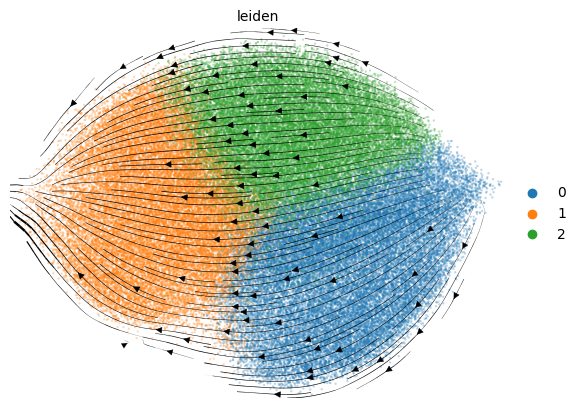

In [92]:
path_delta_x  = np.load("path_a3r10_deltaX.npy")

mroot_ad = dfp.compute_velocity(adata=meanroot_ad, velocity_matrix=path_delta_x,
                    n_neighbors = None, n_jobs=30)
                        
scv.pl.velocity_embedding_stream(mroot_ad,
                                    color='leiden', 
                                    legend_loc='far right', 
                                    )

In [93]:
mroot_ad.write_h5ad(os.path.join(PATH.data_dir, "Perturb_sci/meanroot_sampled_deltax.h5ad"))

# by density

In [78]:
DenseRoot_ad = sc.read_h5ad(os.path.join(PATH.data_dir, "Perturb_sci/bydensity_Apr16.h5ad"))

In [79]:
DenseRoot_ad.uns['iroot']

69250

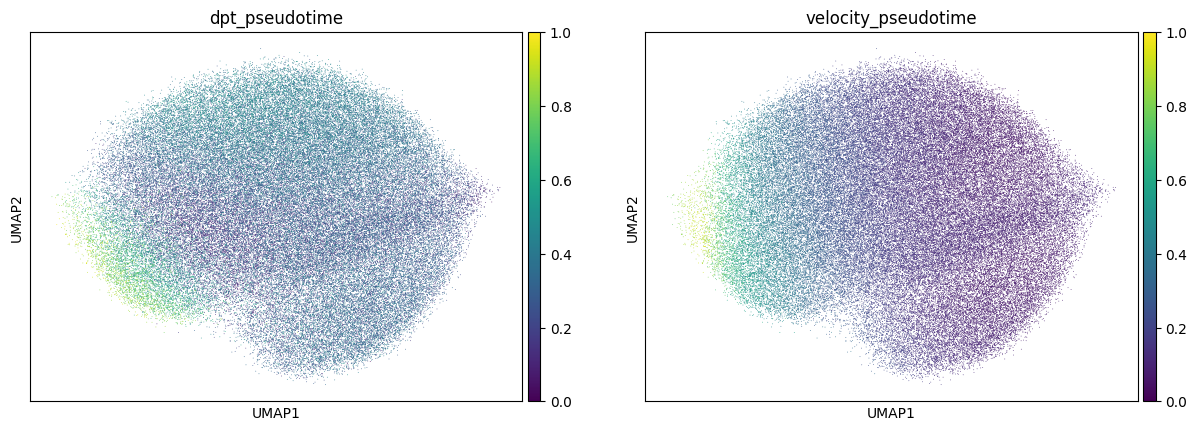

In [80]:
sc.pl.umap(DenseRoot_ad, color=['dpt_pseudotime', 'velocity_pseudotime'])

In [81]:
# only run once
relative_path = "configs/Perturb-kinetics/PathSampler/a3r10-densityroot.yaml"
path_delta_x = dfp.sample_Delta_X(yaml_path = relative_path,
                sampling_repeat = 1
                    )
np.save("path_a3r10_denseroot.npy", path_delta_x)

Sample data using dataset class Path_Diffuse
preparing dataloaders ...
loading adata ...
Sampling ...


100%|██████████| 279/279 [02:31<00:00,  1.84it/s]


In [138]:
path_delta_x = np.load("path_a3r10_denseroot.npy")

path_delta_x = np.where(np.isnan(path_delta_x), np.zeros_like(path_delta_x), path_delta_x = path_delta_x)

In [139]:
np.isnan(path_delta_x)

3459787

computing velocity graph (using 20/40 cores)


  0%|          | 0/89273 [00:00<?, ?cells/s]

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/pytorch_lightning/utilities/seed.py:48: LightningDeprecationWarning: `pytorch_lightning.utilities.seed.seed_everything` has been deprecated in v1.8.0 and will be removed in v2.0.0. Please use `lightning_fabric.utilities.seed.seed_everything` instead.
  rank_zero_deprecation(
Global seed set to 0
/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/pytorch_lightning/utilities/seed.py:48: LightningDeprecationWarning: `pytorch_lightning.utilities.seed.seed_everything` has been deprecated in v1.8.0 and will be removed in v2.0.0. Please use `lightning_fabric.utilities.seed.seed_everything` instead.
  rank_zero_deprecation(
Global seed set to 0
/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/pytorch_lightning/utilities/seed.py:48: LightningDeprecationWarning: `pytorch_lightning.utilities.seed.seed_everything` has been deprecated in v1.8.0 and will be removed in v2.0.0. Please use `lightning_fabric.u

    finished (0:01:39) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:17) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


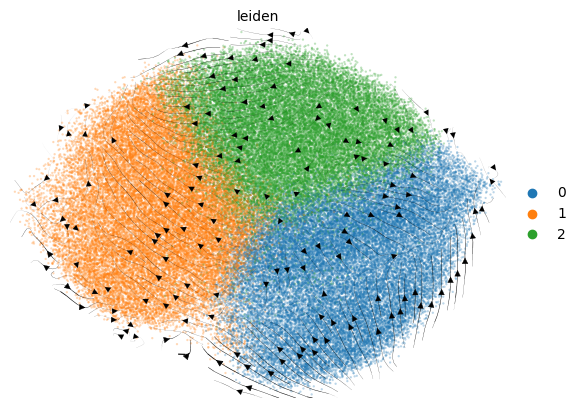

In [83]:
path_adata = dfp.compute_velocity(adata=DenseRoot_ad, velocity_matrix=path_delta_x,
                    n_neighbors = None, n_jobs=20)

scv.pl.velocity_embedding_stream(path_adata,
                                    color='leiden', 
                                    legend_loc='far right', 
                                    )

In [87]:
path_adata.write_h5ad(os.path.join(PATH.data_dir, 'Perturb_sci/densityRoot_sampled_deltax.h5ad'))

# calculate the correlation

In [6]:
from scipy import stats

from tqdm.notebook import tqdm

from matplotlib import pyplot as plt

In [7]:
DenseRoot_ad = sc.read_h5ad(os.path.join(PATH.data_dir, "Perturb_sci/bydensity_Apr16.h5ad"))
path_adata = sc.read_h5ad(os.path.join(PATH.data_dir, 'Perturb_sci/densityRoot_sampled_deltax.h5ad'))
mroot_ad = sc.read_h5ad(os.path.join(PATH.data_dir, "Perturb_sci/meanroot_sampled_deltax.h5ad"))

In [9]:
path_adata

AnnData object with n_obs × n_vars = 89273 × 2000
    obs: 'UMI_counts', 'nascent_UMI_counts', 'nascent_ratio', 'target', 'target_genes', 'gRNA_UMI_counts', 'MT_ratio', 'nascent_MT_ratio', 'Cell_cycle_phase', 'whole_exon_ratio', 'new_exon_ratio', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'dpt_pseudotime', 'discrete_time', 'split', 'Depth_from_root', 'is_control', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'velocity_self_transition', 'root_cells', 'end_points', 'velocity_pseudotime'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes'
    uns: 'KNN', 'diffmap_evals', 'hvg', 'iroot', 'leiden', 'leiden_colors', 'leiden_sizes', 'log1p', 'neighbors', 'paga', 'pca', 'target_genes_colors', 'umap', 'unique_toke

<font size=3>Mean Expr Root</font>

In [10]:
# the two part to compare
Delta_X_mr = mroot_ad.layers['velocity']
unspliced_mr = mroot_ad.layers['Count_nascent_tx'].A

In [155]:
corr_r = [stats.pearsonr(Delta_X[:,g], unspliced[:,g]) for g in tqdm(range(Delta_X.shape[1]))]

  0%|          | 0/4000 [00:00<?, ?it/s]

<font size=3>Density Root</font>

In [13]:
# the two part to compare
# fill nan
path_delta_x = np.load("path_a3r10_denseroot.npy")
path_delta_x = np.where(np.isnan(path_delta_x),  np.zeros_like(path_delta_x), path_delta_x)
path_delta_x = -1 * path_delta_x

DenseRoot_ad.layers['Delta_X'] = path_delta_x

In [143]:
# use the Mu instead

DenseRoot_ad.layers['Delta_X'] = path_delta_x

unspliced = DenseRoot_ad.layers['Mu']
nascent = DenseRoot_ad.layers['Count_nascent_tx'].A

assert path_delta_x.shape == unspliced.shape, "delta x must be the same shape as nascent"

In [165]:
corr_r = [stats.pearsonr(path_delta_x[:,g], unspliced[:,g])[0] for g in tqdm(range(path_delta_x.shape[1]))]

path_corr_r = [stats.pearsonr(path_delta_x[:,g], nascent[:,g])[0] for g in tqdm(range(path_delta_x.shape[1]))]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

In [181]:
DenseRoot_ad

AnnData object with n_obs × n_vars = 89273 × 2000
    obs: 'UMI_counts', 'nascent_UMI_counts', 'nascent_ratio', 'target', 'target_genes', 'gRNA_UMI_counts', 'MT_ratio', 'nascent_MT_ratio', 'Cell_cycle_phase', 'whole_exon_ratio', 'new_exon_ratio', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'dpt_pseudotime', 'discrete_time', 'split', 'Depth_from_root', 'is_control', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'velocity_self_transition', 'root_cells', 'end_points', 'velocity_pseudotime'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes'
    uns: 'KNN', 'diffmap_evals', 'hvg', 'iroot', 'leiden', 'leiden_colors', 'leiden_sizes', 'log1p', 'neighbors', 'paga', 'pca', 'target_genes_colors', 'umap', 'unique_toke

# calculate the cosine similarity

In [11]:
from sklearn.metrics import pairwise
from sklearn import preprocessing

In [14]:
# use the Mu instead
path_delta_x = DenseRoot_ad.layers['Delta_X'] 

unspliced = DenseRoot_ad.layers['Mu']
nascent = DenseRoot_ad.layers['Count_nascent_tx'].A

assert path_delta_x.shape == unspliced.shape, "delta x must be the same shape as nascent"

In [194]:
# cosine similarity of Mu Delta x, density root data
cosine_Mu_dr = [pairwise.cosine_similarity(path_delta_x[i], unspliced[i]) for i in tqdm(range(path_delta_x.shape[0]))]

cosine_nat_dr = [pairwise.cosine_similarity(path_delta_x[i], nascent[i]) for i in tqdm(range(path_delta_x.shape[0]))]

  0%|          | 0/89273 [00:00<?, ?it/s]

ValueError: Expected 2D array, got 1D array instead:
array=[-0.1810836196 -0.0024555065  0.1227580309 ...  1.1969479322 -0.0709566176
  0.2727435231].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [15]:
def MinMax_scale(X):
    x_min = np.min(X, axis=0)
    x_max = np.max(X, axis=0)
    x_mean = np.mean(X, axis=0)
    return 2*(X - x_min) / (x_max-x_min) - 1

In [16]:
normed_nascent = MinMax_scale(nascent)
normed_unspliced = MinMax_scale(unspliced)
normed_path_delta_x = MinMax_scale(path_delta_x)

In [17]:
# cosine similarity of Mu Delta x, density root data
cosine_Mu_dr = pairwise.cosine_similarity(normed_path_delta_x, normed_unspliced)
cosine_nat_dr = pairwise.cosine_similarity(normed_path_delta_x, normed_nascent)

(array([2.2000e+01, 1.4100e+02, 3.7500e+02, 2.2440e+03, 2.7910e+04,
        4.6825e+04, 9.7790e+03, 1.6940e+03, 2.5300e+02, 3.0000e+01]),
 array([-0.35828757, -0.28733903, -0.21639049, -0.14544196, -0.07449342,
        -0.00354488,  0.06740366,  0.13835219,  0.20930073,  0.28024927,
         0.35119781]),
 <BarContainer object of 10 artists>)

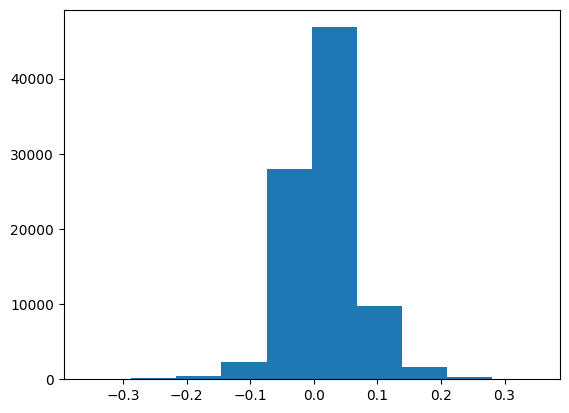

In [20]:
plt.hist(cosine_nat_dr.diagonal());

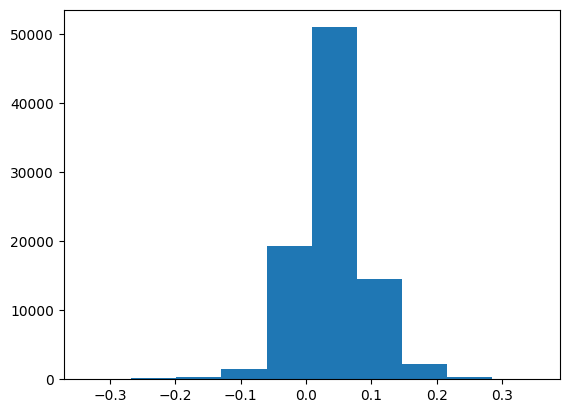

In [21]:
plt.hist(cosine_Mu_dr.diagonal());

# visualize

In [167]:
import seaborn as sns

Text(0.5, 0, 'Pearson correlation r')

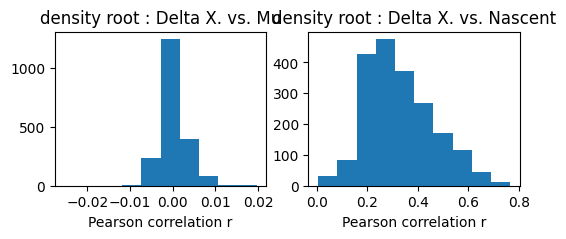

In [166]:
fig, axs = plt.subplots(1,2, figsize=(6,2))

axs[0].hist(corr_r);
axs[0].set_title("density root : Delta X. vs. Mu")
axs[0].set_xlabel("Pearson correlation r")


axs[1].hist(path_corr_r);
axs[1].set_title("density root : Delta X. vs. Nascent")
axs[1].set_xlabel("Pearson correlation r")

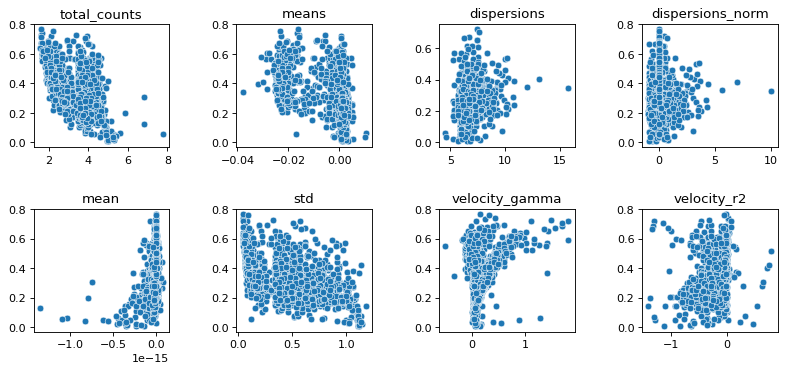

In [179]:
# some properties
gene_props = ['total_counts', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'velocity_gamma', 'velocity_r2']

fig, axs = plt.subplots(2, 4,  figsize=(12, 5), dpi=80, gridspec_kw={'hspace':0.5, 'wspace':0.5})
axs = axs.flatten()

for i, prop in enumerate(gene_props):
    
    x=DenseRoot_ad.var[prop].values
    y=path_corr_r
    
    if prop == 'total_counts':
        x = np.log10(x)
    
    
    sns.scatterplot(x=x, y=y, ax=axs[i])
    axs[i].set_title(prop)

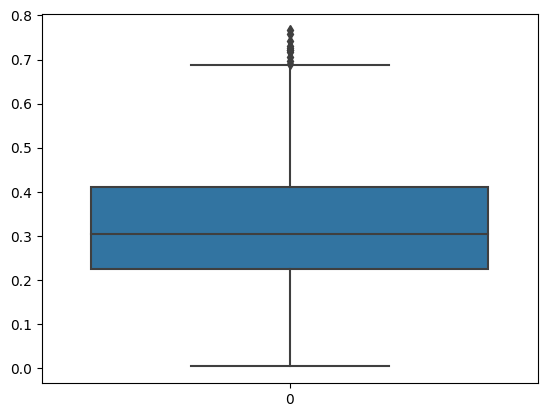

In [169]:
sns.boxplot(path_corr_r);